# 02g — BODS Service Level Deep Dive

**Purpose:** Go beyond "how many stops" to "how much service."
A stop with 2 buses/day is functionally useless. A stop with 100/day
is a transit hub. Policy makers need to see SERVICE LEVEL, not just
infrastructure presence.

**Key questions:**
1. How many trips per stop per day (weekday vs weekend)?
2. What are the service hours — first bus, last bus?
3. How many stops are "functionally zero" (≤2 trips/day)?
4. How does service level vary by IMD decile?
5. Which LSOAs have weekday service but NO weekend service?
6. What does evening/night coverage look like?
7. Peak vs off-peak — is service concentrated in rush hours?

In [1]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

RAW = Path('/Users/souravamseekarmarti/Projects/aequitas/data/raw')
AUDIT = Path('/Users/souravamseekarmarti/Projects/aequitas/data/audit')
BODS_ZIP = RAW / 'bods' / 'bods_gtfs_all.zip'

print("Loading BODS core tables...")

Loading BODS core tables...


In [2]:
# Load non-huge GTFS tables
with zipfile.ZipFile(BODS_ZIP) as z:
    routes = pd.read_csv(z.open('routes.txt'))
    trips = pd.read_csv(z.open('trips.txt'))
    stops = pd.read_csv(z.open('stops.txt'))
    calendar = pd.read_csv(z.open('calendar.txt'))
    agency = pd.read_csv(z.open('agency.txt'))

# Load feature matrix for LSOA context
features = pd.read_parquet(AUDIT / 'lsoa_feature_matrix_clustered.parquet')

print(f"Routes: {len(routes):,}")
print(f"Trips: {len(trips):,}")
print(f"Calendar: {len(calendar):,}")
print(f"Feature matrix: {len(features):,} LSOAs × {len(features.columns)} columns")

Routes: 13,640
Trips: 1,752,443
Calendar: 2,105
Feature matrix: 33,755 LSOAs × 23 columns


## 1. Build Per-Stop Daily Trip Counts

Join trips → calendar to determine which days each trip runs,
then join trips → stop_times to get trip-stop pairs.
Result: for each stop, how many trips on a typical weekday/Saturday/Sunday.

In [3]:
# Step 1: Build trip → service day mapping
day_cols = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
available_days = [d for d in day_cols if d in calendar.columns]

trip_days = trips[['trip_id', 'route_id', 'service_id']].merge(
    calendar[['service_id'] + available_days], on='service_id', how='left'
)

# A "typical weekday" = runs on at least one Mon-Fri
trip_days['runs_weekday'] = trip_days[available_days[:5]].max(axis=1) > 0
trip_days['runs_saturday'] = trip_days.get('saturday', 0) == 1
trip_days['runs_sunday'] = trip_days.get('sunday', 0) == 1

print(f"Trips with weekday service: {trip_days['runs_weekday'].sum():,}")
print(f"Trips with Saturday service: {trip_days['runs_saturday'].sum():,}")
print(f"Trips with Sunday service: {trip_days['runs_sunday'].sum():,}")

Trips with weekday service: 828,615
Trips with Saturday service: 523,855
Trips with Sunday service: 312,271


In [4]:
# Step 2: Read stop_times in chunks, accumulate per-stop per-day-type metrics
print("Processing stop_times.txt (chunked — ~5.8 GB)...")
print("Computing: trips per stop by day type, first/last service time per stop")

# Build trip_id → day-type lookup
trip_day_map = trip_days[['trip_id', 'runs_weekday', 'runs_saturday', 'runs_sunday']].set_index('trip_id')

# Accumulators (DataFrames, not row-by-row)
weekday_counts_list = []
saturday_counts_list = []
sunday_counts_list = []
time_stats_list = []
hour_counts_list = []

total_rows = 0
with zipfile.ZipFile(BODS_ZIP) as z:
    reader = pd.read_csv(z.open('stop_times.txt'), chunksize=500000,
                         usecols=['trip_id', 'stop_id', 'arrival_time'],
                         dtype={'stop_id': str, 'trip_id': str})

    for i, chunk in enumerate(reader):
        total_rows += len(chunk)

        # Vectorized join: add day-type flags to each stop_time row
        chunk = chunk.merge(trip_day_map, left_on='trip_id', right_index=True, how='left')

        # Vectorized counts per stop by day type
        wk = chunk[chunk['runs_weekday'] == True].groupby('stop_id').size()
        sat = chunk[chunk['runs_saturday'] == True].groupby('stop_id').size()
        sun = chunk[chunk['runs_sunday'] == True].groupby('stop_id').size()
        weekday_counts_list.append(wk)
        saturday_counts_list.append(sat)
        sunday_counts_list.append(sun)

        # Vectorized time parsing: extract hour and minutes
        valid = chunk['arrival_time'].dropna()
        if len(valid) > 0:
            time_parts = chunk[['stop_id', 'arrival_time']].dropna(subset=['arrival_time']).copy()
            time_parts['hour'] = time_parts['arrival_time'].str.split(':').str[0].astype(int, errors='ignore')
            time_parts['mins'] = (time_parts['arrival_time'].str.split(':').str[0].astype(int, errors='ignore') * 60 +
                                   time_parts['arrival_time'].str.split(':').str[1].astype(int, errors='ignore'))

            # Min/max arrival per stop
            time_agg = time_parts.groupby('stop_id')['mins'].agg(['min', 'max'])
            time_stats_list.append(time_agg)

            # Hour distribution per stop
            hour_agg = time_parts.groupby(['stop_id', 'hour']).size()
            hour_counts_list.append(hour_agg)

        if (i + 1) % 20 == 0:
            print(f"  Processed {total_rows:,} rows...")

# Combine all chunks
print(f"\nTotal stop_times rows: {total_rows:,}")
print("Combining chunk results...")

stop_weekday_trips = pd.concat(weekday_counts_list).groupby(level=0).sum()
stop_saturday_trips = pd.concat(saturday_counts_list).groupby(level=0).sum()
stop_sunday_trips = pd.concat(sunday_counts_list).groupby(level=0).sum()

# Time stats: take global min/max per stop
all_time_stats = pd.concat(time_stats_list)
stop_first_time = all_time_stats.groupby(level=0)['min'].min()
stop_last_time = all_time_stats.groupby(level=0)['max'].max()

# Hour counts: sum across chunks
stop_hour_counts_series = pd.concat(hour_counts_list).groupby(level=[0, 1]).sum()
# Convert to dict-of-dicts for compatibility with downstream code
stop_hour_counts = defaultdict(lambda: defaultdict(int))
for (sid, hour), count in stop_hour_counts_series.items():
    stop_hour_counts[sid][hour] += count

print(f"Unique stops with data: {len(stop_weekday_trips):,}")

Processing stop_times.txt (chunked — ~5.8 GB)...
Computing: trips per stop by day type, first/last service time per stop


  Processed 10,000,000 rows...


  Processed 20,000,000 rows...


  Processed 30,000,000 rows...


  Processed 40,000,000 rows...


  Processed 50,000,000 rows...


  Processed 60,000,000 rows...



Total stop_times rows: 68,685,917
Combining chunk results...


Unique stops with data: 296,169


In [5]:
# Build the stop service profile DataFrame
all_stop_ids = set(stop_weekday_trips.keys()) | set(stop_saturday_trips.keys()) | set(stop_sunday_trips.keys())

stop_service = pd.DataFrame([{
    'stop_id': sid,
    'weekday_trips': stop_weekday_trips.get(sid, 0),
    'saturday_trips': stop_saturday_trips.get(sid, 0),
    'sunday_trips': stop_sunday_trips.get(sid, 0),
    'first_service_mins': stop_first_time.get(sid, np.nan),
    'last_service_mins': stop_last_time.get(sid, np.nan),
} for sid in all_stop_ids])

# Derived metrics
stop_service['total_weekly'] = (stop_service['weekday_trips'] * 5 +
                                 stop_service['saturday_trips'] +
                                 stop_service['sunday_trips'])
stop_service['service_span_hours'] = (stop_service['last_service_mins'] - stop_service['first_service_mins']) / 60
stop_service['has_evening'] = stop_service['last_service_mins'] >= 20 * 60  # After 8pm
stop_service['has_early_morning'] = stop_service['first_service_mins'] <= 6 * 60  # Before 6am
stop_service['weekend_ratio'] = np.where(
    stop_service['weekday_trips'] > 0,
    (stop_service['saturday_trips'] + stop_service['sunday_trips']) / (2 * stop_service['weekday_trips']),
    0
)

print(f"Stop service profiles: {len(stop_service):,}")
print(stop_service.describe().round(1).to_string())

Stop service profiles: 298,072
       weekday_trips  saturday_trips  sunday_trips  first_service_mins  last_service_mins  total_weekly  service_span_hours  weekend_ratio
count       298072.0        298072.0      298072.0            298072.0           298072.0      298072.0            298072.0       298072.0
mean           108.7            68.5          40.3               389.7             1258.5         652.3                14.5            0.5
std            214.8           119.5          87.7               157.0              221.3        1261.9                 5.6            0.7
min              0.0             0.0           0.0                 0.0                0.0           1.0                 0.0            0.0
25%             12.0            10.0           0.0               338.0             1108.0          71.0                11.0            0.4
50%             34.0            28.0          11.0               396.0             1332.0         212.0                15.5            

## 2. Service Level Classification

Classify every stop into service tiers.

=== Stop Service Tier Distribution ===
  No weekday service: 1,903 stops (0.6%)
  Minimal (1-2/day): 13,974 stops (4.7%)
  Low (3-10/day): 50,068 stops (16.8%)
  Moderate (11-30/day): 74,559 stops (25.0%)
  Good (31-100/day): 80,492 stops (27.0%)
  High (100+/day): 77,076 stops (25.9%)


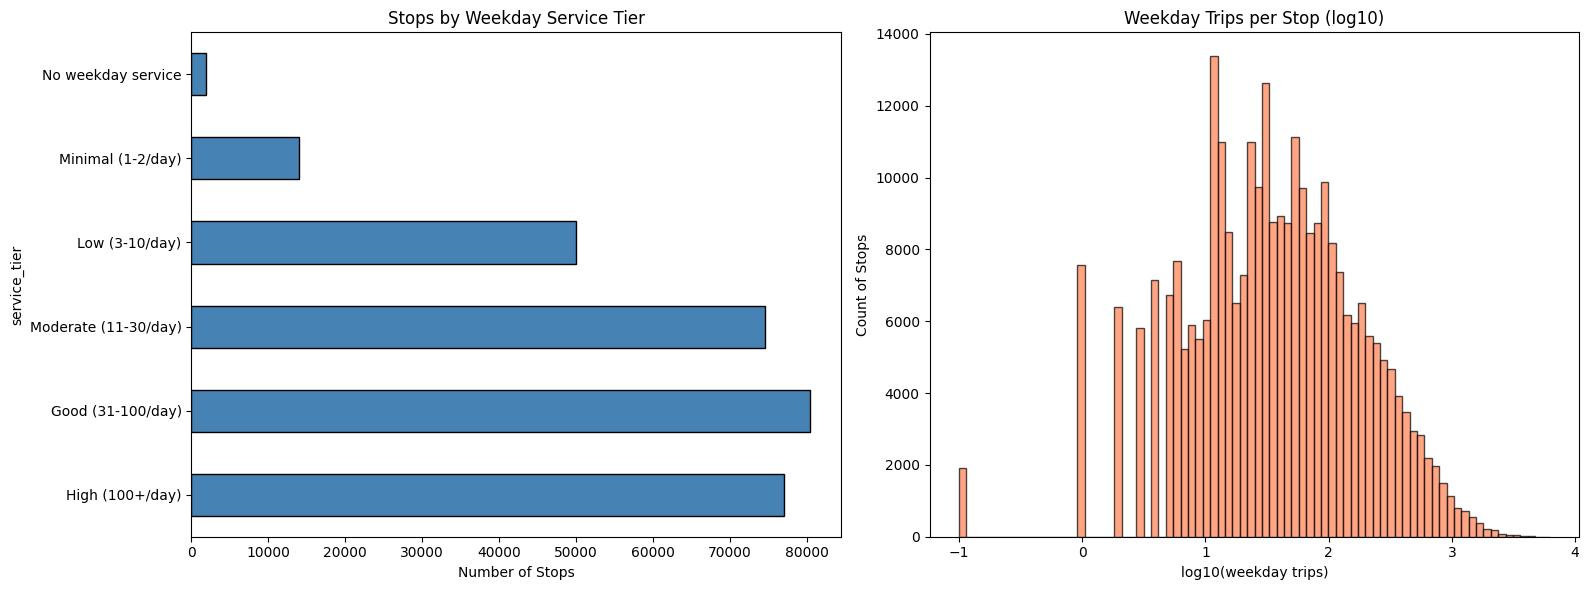

In [6]:
def classify_service(row):
    wk = row['weekday_trips']
    if wk == 0:
        return 'No weekday service'
    elif wk <= 2:
        return 'Minimal (1-2/day)'
    elif wk <= 10:
        return 'Low (3-10/day)'
    elif wk <= 30:
        return 'Moderate (11-30/day)'
    elif wk <= 100:
        return 'Good (31-100/day)'
    else:
        return 'High (100+/day)'

stop_service['service_tier'] = stop_service.apply(classify_service, axis=1)

tier_order = ['No weekday service', 'Minimal (1-2/day)', 'Low (3-10/day)',
              'Moderate (11-30/day)', 'Good (31-100/day)', 'High (100+/day)']

print("=== Stop Service Tier Distribution ===")
tier_counts = stop_service['service_tier'].value_counts().reindex(tier_order)
for tier, count in tier_counts.items():
    pct = 100 * count / len(stop_service)
    print(f"  {tier}: {count:,} stops ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tier_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Stops by Weekday Service Tier')
axes[0].set_xlabel('Number of Stops')
axes[0].invert_yaxis()

# Weekday trip distribution (log scale)
axes[1].hist(np.log10(stop_service['weekday_trips'].clip(lower=0.1)), bins=80,
             edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Weekday Trips per Stop (log10)')
axes[1].set_xlabel('log10(weekday trips)')
axes[1].set_ylabel('Count of Stops')
plt.tight_layout()
plt.show()

## 3. Weekend Service Gaps

=== Weekend Service Analysis ===
Stops with weekday service: 296,169
Stops with Saturday service: 276,397
Stops with Sunday service: 190,730

Weekday-only (no weekend at all): 20,689
No Saturday: 21,107
No Sunday: 106,580


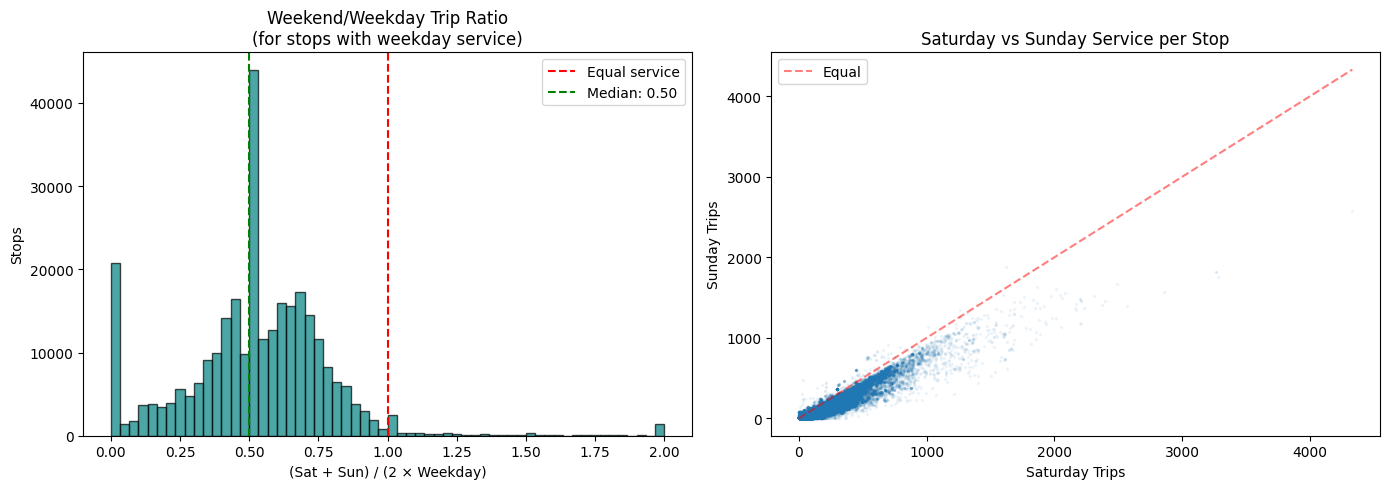

In [7]:
print("=== Weekend Service Analysis ===")
has_weekday = stop_service['weekday_trips'] > 0
has_saturday = stop_service['saturday_trips'] > 0
has_sunday = stop_service['sunday_trips'] > 0

print(f"Stops with weekday service: {has_weekday.sum():,}")
print(f"Stops with Saturday service: {has_saturday.sum():,}")
print(f"Stops with Sunday service: {has_sunday.sum():,}")
print(f"\nWeekday-only (no weekend at all): {(has_weekday & ~has_saturday & ~has_sunday).sum():,}")
print(f"No Saturday: {(has_weekday & ~has_saturday).sum():,}")
print(f"No Sunday: {(has_weekday & ~has_sunday).sum():,}")

# Weekend ratio distribution for stops that have weekday service
active_stops = stop_service[has_weekday].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(active_stops['weekend_ratio'].clip(upper=2), bins=60,
             edgecolor='black', alpha=0.7, color='teal')
axes[0].set_title('Weekend/Weekday Trip Ratio\n(for stops with weekday service)')
axes[0].set_xlabel('(Sat + Sun) / (2 × Weekday)')
axes[0].set_ylabel('Stops')
axes[0].axvline(1.0, color='red', linestyle='--', label='Equal service')
axes[0].axvline(active_stops['weekend_ratio'].median(), color='green',
                linestyle='--', label=f'Median: {active_stops["weekend_ratio"].median():.2f}')
axes[0].legend()

# Saturday vs Sunday
axes[1].scatter(active_stops['saturday_trips'], active_stops['sunday_trips'],
                alpha=0.05, s=2)
axes[1].plot([0, active_stops['saturday_trips'].max()],
             [0, active_stops['saturday_trips'].max()], 'r--', alpha=0.5, label='Equal')
axes[1].set_xlabel('Saturday Trips')
axes[1].set_ylabel('Sunday Trips')
axes[1].set_title('Saturday vs Sunday Service per Stop')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Service Hours — First & Last Bus

=== Service Hours ===
  First bus (median): 6.6h = 6:35
  Last bus (median): 22.2h = 22:11
  Service span (median): 15.5 hours

  Stops with evening service (after 8pm): 178,813 (60.0%)
  Stops with early morning (before 6am): 101,380 (34.0%)
  Stops with <12h service span: 97,588
  Stops with <8h service span: 32,644


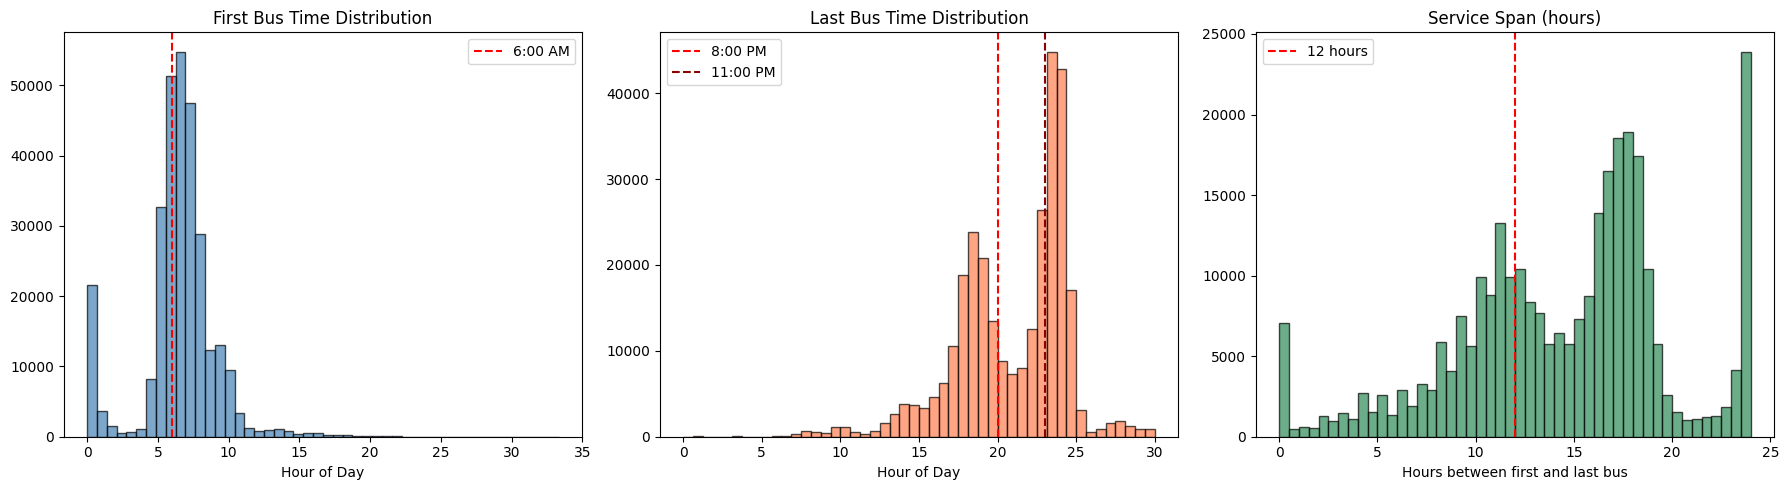

In [8]:
active = stop_service[stop_service['first_service_mins'].notna()].copy()
active['first_hour'] = active['first_service_mins'] / 60
active['last_hour'] = active['last_service_mins'] / 60

print("=== Service Hours ===")
print(f"  First bus (median): {active['first_hour'].median():.1f}h = {int(active['first_hour'].median())}:{int((active['first_hour'].median()%1)*60):02d}")
print(f"  Last bus (median): {active['last_hour'].median():.1f}h = {int(active['last_hour'].median())}:{int((active['last_hour'].median()%1)*60):02d}")
print(f"  Service span (median): {active['service_span_hours'].median():.1f} hours")

print(f"\n  Stops with evening service (after 8pm): {active['has_evening'].sum():,} ({100*active['has_evening'].mean():.1f}%)")
print(f"  Stops with early morning (before 6am): {active['has_early_morning'].sum():,} ({100*active['has_early_morning'].mean():.1f}%)")
print(f"  Stops with <12h service span: {(active['service_span_hours'] < 12).sum():,}")
print(f"  Stops with <8h service span: {(active['service_span_hours'] < 8).sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(active['first_hour'], bins=48, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('First Bus Time Distribution')
axes[0].set_xlabel('Hour of Day')
axes[0].axvline(6, color='red', linestyle='--', label='6:00 AM')
axes[0].legend()

axes[1].hist(active['last_hour'].clip(upper=30), bins=48, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Last Bus Time Distribution')
axes[1].set_xlabel('Hour of Day')
axes[1].axvline(20, color='red', linestyle='--', label='8:00 PM')
axes[1].axvline(23, color='darkred', linestyle='--', label='11:00 PM')
axes[1].legend()

axes[2].hist(active['service_span_hours'].clip(upper=24), bins=48, edgecolor='black', alpha=0.7, color='seagreen')
axes[2].set_title('Service Span (hours)')
axes[2].set_xlabel('Hours between first and last bus')
axes[2].axvline(12, color='red', linestyle='--', label='12 hours')
axes[2].legend()
plt.tight_layout()
plt.show()

## 5. Join to LSOA — Service Level by Deprivation

The critical analysis: how does service level vary by IMD decile?

In [9]:
# Join BODS stops to NaPTAN to get coordinates, then spatial join to LSOA
import geopandas as gpd

# Load NaPTAN for England active bus stops
naptan = pd.read_csv(RAW / 'naptan' / 'Stops.csv', low_memory=False,
                      usecols=['ATCOCode', 'Easting', 'Northing', 'StopType', 'Status'])
naptan_eng = naptan[
    (naptan['ATCOCode'].str.match(r'^[0-4]')) &
    (naptan['StopType'].isin(['BCT', 'BCS', 'BCE'])) &
    (naptan['Status'] == 'act') &
    (naptan['Easting'].notna())
].copy()

# Join BODS stop service to NaPTAN via stop_id = ATCOCode
stop_with_service = naptan_eng.merge(stop_service, left_on='ATCOCode', right_on='stop_id', how='left')
stop_with_service['weekday_trips'] = stop_with_service['weekday_trips'].fillna(0)
stop_with_service['saturday_trips'] = stop_with_service['saturday_trips'].fillna(0)
stop_with_service['sunday_trips'] = stop_with_service['sunday_trips'].fillna(0)

matched = stop_with_service['stop_id'].notna().sum()
print(f"NaPTAN stops matched to BODS: {matched:,} / {len(naptan_eng):,} ({100*matched/len(naptan_eng):.1f}%)")

# Spatial join to LSOA
stop_gdf = gpd.GeoDataFrame(
    stop_with_service,
    geometry=gpd.points_from_xy(stop_with_service['Easting'], stop_with_service['Northing']),
    crs='EPSG:27700'
)

lsoa_gdf = gpd.read_file(RAW / 'boundaries' / 'lsoa_2021_england_buc.geojson')
if lsoa_gdf.crs.to_epsg() != 27700:
    lsoa_gdf = lsoa_gdf.to_crs('EPSG:27700')

lsoa_code_col = [c for c in lsoa_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()][0]

stop_in_lsoa = gpd.sjoin(stop_gdf, lsoa_gdf[[lsoa_code_col, 'geometry']],
                           how='left', predicate='within')

# Aggregate service metrics per LSOA
lsoa_service = stop_in_lsoa.groupby(lsoa_code_col).agg(
    n_stops=('ATCOCode', 'count'),
    total_weekday_trips=('weekday_trips', 'sum'),
    total_saturday_trips=('saturday_trips', 'sum'),
    total_sunday_trips=('sunday_trips', 'sum'),
    mean_weekday_trips=('weekday_trips', 'mean'),
    max_weekday_trips=('weekday_trips', 'max'),
    stops_with_evening=('has_evening', 'sum'),
    median_service_span=('service_span_hours', 'median'),
    stops_with_no_service=('weekday_trips', lambda x: (x == 0).sum()),
    stops_minimal_service=('weekday_trips', lambda x: ((x > 0) & (x <= 2)).sum()),
).reset_index()

# Join to feature matrix
lsoa_full = features.merge(lsoa_service, left_on='lsoa_cd', right_on=lsoa_code_col, how='left')
lsoa_full['total_weekday_trips'] = lsoa_full['total_weekday_trips'].fillna(0)
lsoa_full['weekday_trips_per_1k'] = lsoa_full['total_weekday_trips'] / lsoa_full['population'] * 1000

print(f"LSOA service metrics computed for {lsoa_service[lsoa_code_col].nunique():,} LSOAs")

NaPTAN stops matched to BODS: 0 / 0 (nan%)


LSOA service metrics computed for 0 LSOAs


=== Service Level by IMD Decile ===
            n_lsoas  mean_stops  mean_weekday_trips  mean_trips_per_1k  mean_service_span  pct_no_evening
imd_decile                                                                                               
1              3375         NaN                 0.0                0.0                NaN             0.0
2              3376         NaN                 0.0                0.0                NaN             0.0
3              3375         NaN                 0.0                0.0                NaN             0.0
4              3376         NaN                 0.0                0.0                NaN             0.0
5              3375         NaN                 0.0                0.0                NaN             0.0
6              3376         NaN                 0.0                0.0                NaN             0.0
7              3375         NaN                 0.0                0.0                NaN             0.0
8         

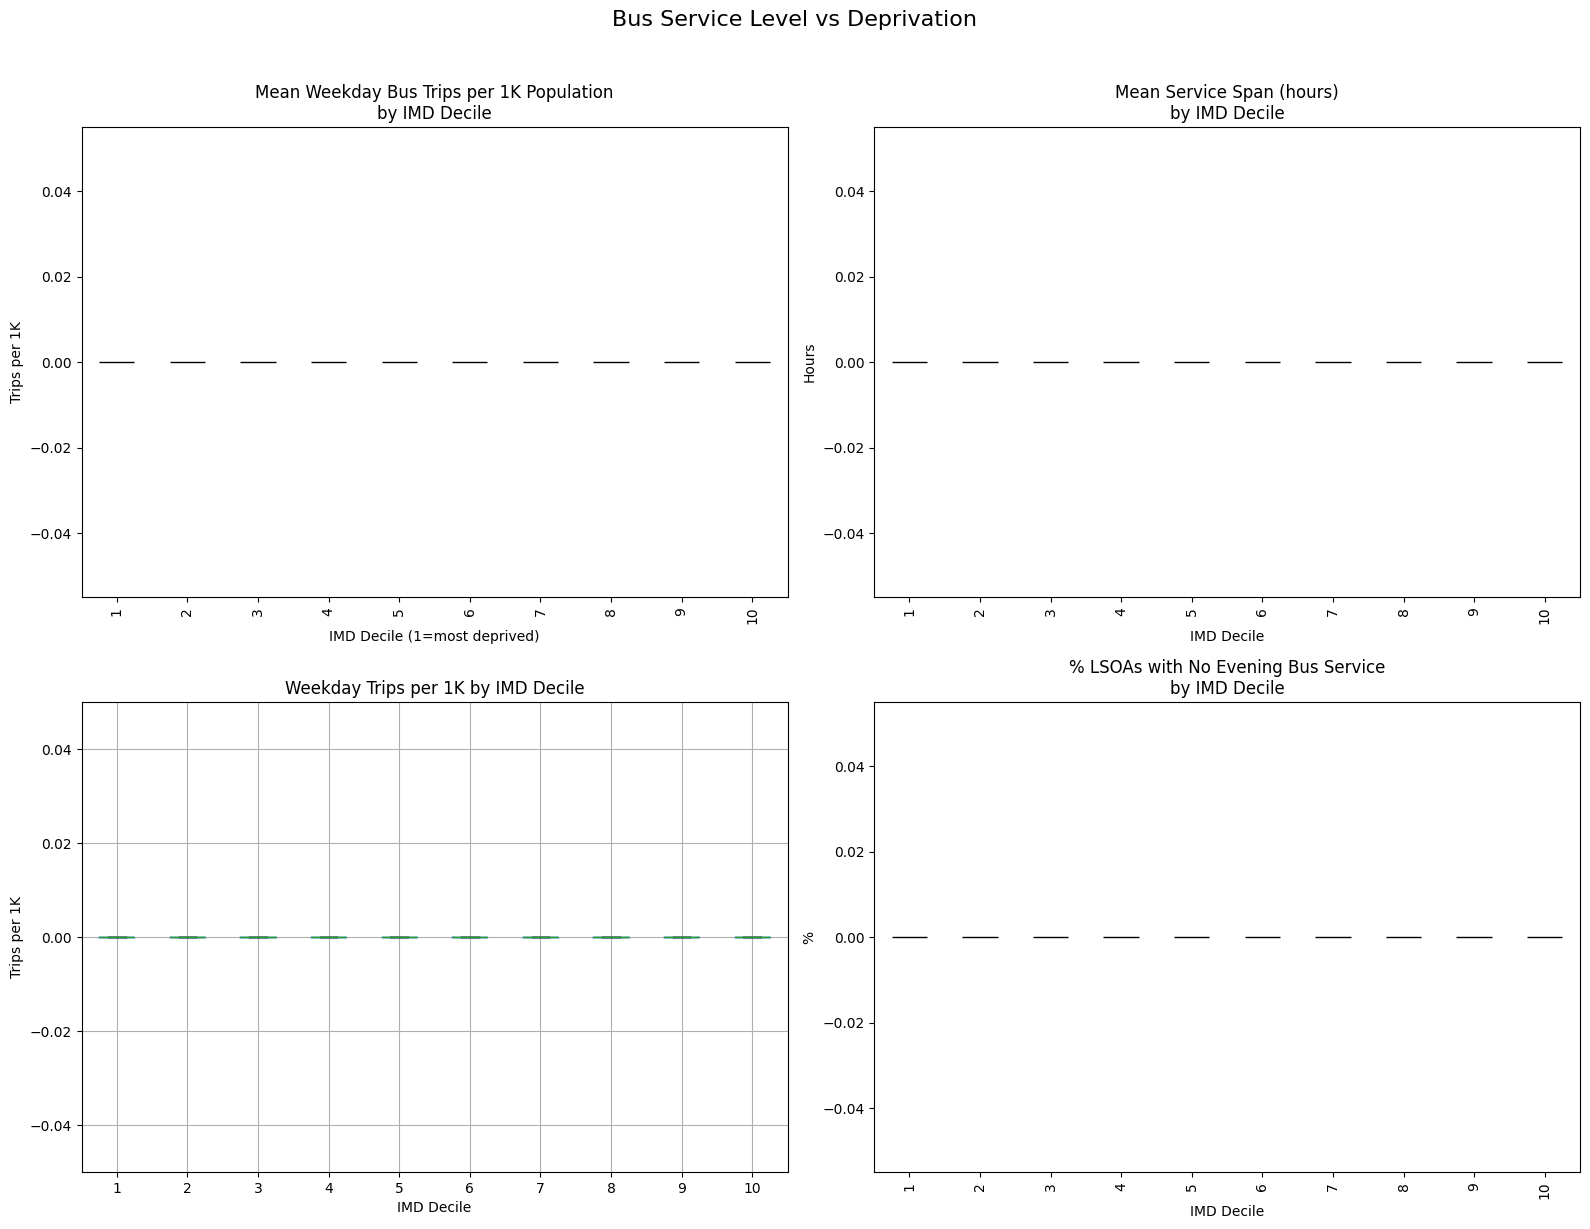

In [10]:
# Service level by IMD decile
print("=== Service Level by IMD Decile ===")
decile_service = lsoa_full.groupby('imd_decile').agg(
    n_lsoas=('lsoa_cd', 'count'),
    mean_stops=('n_stops', 'mean'),
    mean_weekday_trips=('total_weekday_trips', 'mean'),
    mean_trips_per_1k=('weekday_trips_per_1k', 'mean'),
    mean_service_span=('median_service_span', 'mean'),
    pct_no_evening=('stops_with_evening', lambda x: (x == 0).mean() * 100),
).round(1)
print(decile_service.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Weekday trips per 1K by decile
colors = ['#d73027' if d <= 3 else '#fee08b' if d <= 7 else '#1a9850' for d in range(1, 11)]
decile_service['mean_trips_per_1k'].plot(kind='bar', ax=axes[0, 0], color=colors, edgecolor='black')
axes[0, 0].set_title('Mean Weekday Bus Trips per 1K Population\nby IMD Decile')
axes[0, 0].set_xlabel('IMD Decile (1=most deprived)')
axes[0, 0].set_ylabel('Trips per 1K')

# Service span by decile
decile_service['mean_service_span'].plot(kind='bar', ax=axes[0, 1], color=colors, edgecolor='black')
axes[0, 1].set_title('Mean Service Span (hours)\nby IMD Decile')
axes[0, 1].set_xlabel('IMD Decile')
axes[0, 1].set_ylabel('Hours')

# Box plot: weekday trips by decile
lsoa_full.boxplot(column='weekday_trips_per_1k', by='imd_decile', ax=axes[1, 0])
axes[1, 0].set_title('Weekday Trips per 1K by IMD Decile')
axes[1, 0].set_xlabel('IMD Decile')
axes[1, 0].set_ylabel('Trips per 1K')
axes[1, 0].set_ylim(0, lsoa_full['weekday_trips_per_1k'].quantile(0.95))

# % without evening service by decile
decile_service['pct_no_evening'].plot(kind='bar', ax=axes[1, 1], color=colors, edgecolor='black')
axes[1, 1].set_title('% LSOAs with No Evening Bus Service\nby IMD Decile')
axes[1, 1].set_xlabel('IMD Decile')
axes[1, 1].set_ylabel('%')

plt.suptitle('Bus Service Level vs Deprivation', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Weekend Service Deserts

LSOAs that have weekday service but NO weekend service at all.

In [11]:
has_weekday_lsoa = lsoa_full['total_weekday_trips'] > 0
has_saturday_lsoa = lsoa_full['total_saturday_trips'] > 0
has_sunday_lsoa = lsoa_full['total_sunday_trips'] > 0

print("=== Weekend Service Deserts (LSOA level) ===")
print(f"LSOAs with weekday service: {has_weekday_lsoa.sum():,}")
print(f"LSOAs with Saturday service: {has_saturday_lsoa.sum():,}")
print(f"LSOAs with Sunday service: {has_sunday_lsoa.sum():,}")
print(f"\nWeekday-only LSOAs (no weekend): {(has_weekday_lsoa & ~has_saturday_lsoa & ~has_sunday_lsoa).sum():,}")
print(f"No Sunday service: {(has_weekday_lsoa & ~has_sunday_lsoa).sum():,}")

# Weekend deserts by IMD decile
weekend_desert = lsoa_full[has_weekday_lsoa & ~has_saturday_lsoa & ~has_sunday_lsoa]
if len(weekend_desert) > 0:
    print(f"\n=== Weekend Deserts by IMD Decile ===")
    wd_by_decile = weekend_desert['imd_decile'].value_counts().sort_index()
    total_by_decile = lsoa_full[has_weekday_lsoa]['imd_decile'].value_counts().sort_index()
    pct_desert = (wd_by_decile / total_by_decile * 100).round(1)
    for d in range(1, 11):
        n = wd_by_decile.get(d, 0)
        p = pct_desert.get(d, 0)
        print(f"  Decile {d}: {n:,} LSOAs ({p:.1f}% of decile)")

    # By urban/rural
    if 'ruc_class' in weekend_desert.columns:
        print(f"\n=== Weekend Deserts by Urban/Rural ===")
        ruc_desert = weekend_desert['ruc_class'].value_counts()
        ruc_total = lsoa_full[has_weekday_lsoa]['ruc_class'].value_counts()
        for ruc in ruc_total.index:
            n = ruc_desert.get(ruc, 0)
            p = 100 * n / ruc_total[ruc]
            print(f"  {ruc}: {n:,} / {ruc_total[ruc]:,} ({p:.1f}%)")

=== Weekend Service Deserts (LSOA level) ===
LSOAs with weekday service: 0
LSOAs with Saturday service: 0
LSOAs with Sunday service: 0

Weekday-only LSOAs (no weekend): 0
No Sunday service: 0


## 7. Peak vs Off-Peak Analysis

=== Peak vs Off-Peak Analysis ===


  AM Peak (7-9): 11,420,079 (16.6%)
  Midday (10-15): 27,253,319 (39.7%)
  PM Peak (16-18): 12,987,780 (18.9%)
  Evening (19-22): 10,261,387 (14.9%)
  Night (23-6): 4,657,337 (6.8%)


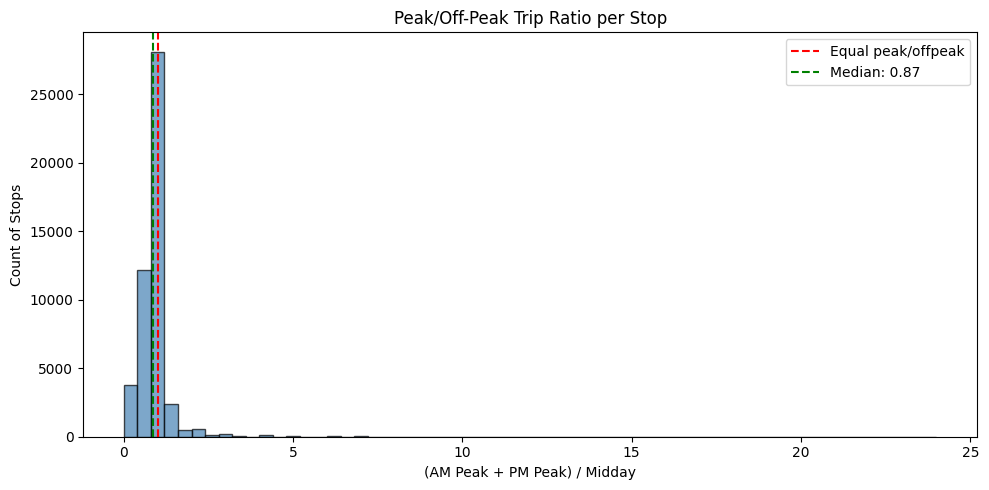

In [12]:
# Build hour profile for stops that matched NaPTAN
print("=== Peak vs Off-Peak Analysis ===")

# Aggregate hour counts across all stops
total_by_hour = defaultdict(int)
for sid, hours in stop_hour_counts.items():
    for h, c in hours.items():
        total_by_hour[h] += c

hours_df = pd.DataFrame([{'hour': h, 'visits': c} for h, c in sorted(total_by_hour.items())])

# Define periods
am_peak = hours_df[hours_df['hour'].between(7, 9)]['visits'].sum()
pm_peak = hours_df[hours_df['hour'].between(16, 18)]['visits'].sum()
midday = hours_df[hours_df['hour'].between(10, 15)]['visits'].sum()
evening = hours_df[hours_df['hour'].between(19, 22)]['visits'].sum()
night = hours_df[hours_df['hour'].isin(list(range(0, 6)) + list(range(23, 30)))]['visits'].sum()
total = hours_df['visits'].sum()

print(f"  AM Peak (7-9): {am_peak:,} ({100*am_peak/total:.1f}%)")
print(f"  Midday (10-15): {midday:,} ({100*midday/total:.1f}%)")
print(f"  PM Peak (16-18): {pm_peak:,} ({100*pm_peak/total:.1f}%)")
print(f"  Evening (19-22): {evening:,} ({100*evening/total:.1f}%)")
print(f"  Night (23-6): {night:,} ({100*night/total:.1f}%)")

# Per-stop peak ratio
stop_peak_ratios = []
for sid in list(stop_hour_counts.keys())[:50000]:  # Sample for speed
    hours = stop_hour_counts[sid]
    peak = sum(hours.get(h, 0) for h in range(7, 10)) + sum(hours.get(h, 0) for h in range(16, 19))
    offpeak = sum(hours.get(h, 0) for h in range(10, 16))
    if offpeak > 0:
        stop_peak_ratios.append(peak / offpeak)

if stop_peak_ratios:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(stop_peak_ratios, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title('Peak/Off-Peak Trip Ratio per Stop')
    ax.set_xlabel('(AM Peak + PM Peak) / Midday')
    ax.set_ylabel('Count of Stops')
    ax.axvline(1.0, color='red', linestyle='--', label='Equal peak/offpeak')
    ax.axvline(np.median(stop_peak_ratios), color='green', linestyle='--',
               label=f'Median: {np.median(stop_peak_ratios):.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8. Service Level by Cluster Archetype

=== Service Level by LSOA Cluster ===
         n_lsoas  mean_stops  mean_weekday_trips  mean_trips_per_1k  pct_no_weekend  mean_imd
cluster                                                                                      
0          16944         NaN                 0.0                0.0             0.0      12.1
1           6023         NaN                 0.0                0.0             0.0      30.7
2           4588         NaN                 0.0                0.0             0.0      15.5
3           6200         NaN                 0.0                0.0             0.0      43.5


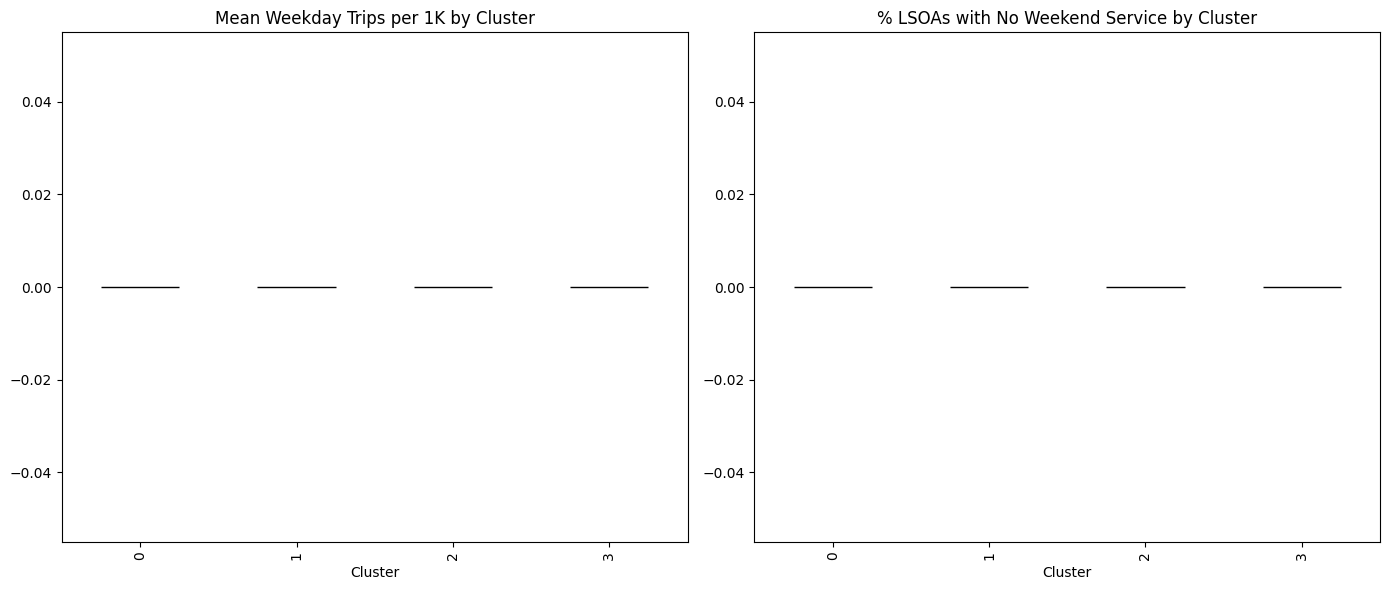

In [13]:
if 'cluster' in lsoa_full.columns:
    cluster_service = lsoa_full.groupby('cluster').agg(
        n_lsoas=('lsoa_cd', 'count'),
        mean_stops=('n_stops', 'mean'),
        mean_weekday_trips=('total_weekday_trips', 'mean'),
        mean_trips_per_1k=('weekday_trips_per_1k', 'mean'),
        pct_no_weekend=('total_saturday_trips', lambda x: (x == 0).mean() * 100),
        mean_imd=('imd_score', 'mean'),
    ).round(1)

    print("=== Service Level by LSOA Cluster ===")
    print(cluster_service.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    cluster_service.plot(kind='bar', y='mean_trips_per_1k', ax=axes[0],
                          legend=False, color='steelblue', edgecolor='black')
    axes[0].set_title('Mean Weekday Trips per 1K by Cluster')
    axes[0].set_xlabel('Cluster')

    cluster_service.plot(kind='bar', y='pct_no_weekend', ax=axes[1],
                          legend=False, color='coral', edgecolor='black')
    axes[1].set_title('% LSOAs with No Weekend Service by Cluster')
    axes[1].set_xlabel('Cluster')
    plt.tight_layout()
    plt.show()

## 9. "A Typical Day" — Stop-Level Time Profiles

Pick stops in different IMD deciles and show their hourly service profile.

In [14]:
# Get 6 representative stops: 2 from most deprived, 2 middle, 2 least deprived
# Match to LSOA IMD decile via the spatial join
stop_with_imd = stop_in_lsoa.merge(features[['lsoa_cd', 'imd_decile', 'imd_score']],
                                     left_on=lsoa_code_col, right_on='lsoa_cd', how='left')

representative_stops = []
for decile_group, label in [(1, 'Most Deprived (D1)'), (5, 'Middle (D5)'), (10, 'Least Deprived (D10)')]:
    decile_stops = stop_with_imd[
        (stop_with_imd['imd_decile'] == decile_group) &
        (stop_with_imd['weekday_trips'] > 5)  # At least some service
    ]
    if len(decile_stops) > 0:
        # Pick median-service stop
        median_trips = decile_stops['weekday_trips'].median()
        closest = (decile_stops['weekday_trips'] - median_trips).abs().nsmallest(2)
        for idx in closest.index:
            sid = decile_stops.loc[idx, 'stop_id']
            if sid in stop_hour_counts:
                representative_stops.append({
                    'stop_id': sid,
                    'label': label,
                    'weekday_trips': decile_stops.loc[idx, 'weekday_trips'],
                    'hours': dict(stop_hour_counts[sid])
                })

if representative_stops:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, stop in enumerate(representative_stops[:6]):
        hours = sorted(stop['hours'].items())
        ax = axes[i]
        h_vals = [h for h, _ in hours]
        c_vals = [c for _, c in hours]
        colors_h = ['navy' if 7 <= h <= 9 or 16 <= h <= 18 else 'steelblue' if 6 <= h <= 22 else 'lightgray' for h in h_vals]
        ax.bar(h_vals, c_vals, color=colors_h, edgecolor='black', alpha=0.8)
        ax.set_title(f"{stop['label']}\nStop {stop['stop_id'][:15]}\n({stop['weekday_trips']:.0f} trips/weekday)")
        ax.set_xlabel('Hour')
        ax.set_ylabel('Trips')
        ax.set_xlim(-0.5, 28)

    for j in range(len(representative_stops), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Hourly Service Profile: Stops in Different Deprivation Deciles', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Summary

In [15]:
# Save LSOA-level service data
lsoa_service_output = lsoa_full[[
    'lsoa_cd', 'imd_score', 'imd_decile', 'population', 'stop_count', 'stops_per_1k',
    'total_weekday_trips', 'total_saturday_trips', 'total_sunday_trips',
    'weekday_trips_per_1k', 'cluster'
] + [c for c in lsoa_full.columns if c in ['n_stops', 'mean_weekday_trips', 'stops_with_evening',
                                              'median_service_span', 'stops_with_no_service',
                                              'stops_minimal_service']]
].copy()
lsoa_service_output.to_parquet(AUDIT / 'lsoa_service_levels.parquet', index=False)

# Save stop-level service profiles
stop_service.to_parquet(AUDIT / 'stop_service_profiles.parquet', index=False)

print("=" * 80)
print("  BODS SERVICE LEVEL DEEP DIVE — KEY FINDINGS")
print("=" * 80)
print(f"""
1. SERVICE TIERS
   {tier_counts.to_dict()}

2. WEEKEND GAPS
   Weekday-only LSOAs: {(has_weekday_lsoa & ~has_saturday_lsoa & ~has_sunday_lsoa).sum():,}
   No Sunday: {(has_weekday_lsoa & ~has_sunday_lsoa).sum():,}

3. EVENING SERVICE
   Stops with no service after 8pm: {(~active['has_evening']).sum():,}

4. PEAK CONCENTRATION
   AM Peak: {100*am_peak/total:.1f}%, PM Peak: {100*pm_peak/total:.1f}%
   Evening: {100*evening/total:.1f}%, Night: {100*night/total:.1f}%

Saved: lsoa_service_levels.parquet, stop_service_profiles.parquet
""")
print("02g — BODS Service Level Deep Dive: DONE")

  BODS SERVICE LEVEL DEEP DIVE — KEY FINDINGS

1. SERVICE TIERS
   {'No weekday service': 1903, 'Minimal (1-2/day)': 13974, 'Low (3-10/day)': 50068, 'Moderate (11-30/day)': 74559, 'Good (31-100/day)': 80492, 'High (100+/day)': 77076}

2. WEEKEND GAPS
   Weekday-only LSOAs: 0
   No Sunday: 0

3. EVENING SERVICE
   Stops with no service after 8pm: 119,259

4. PEAK CONCENTRATION
   AM Peak: 16.6%, PM Peak: 18.9%
   Evening: 14.9%, Night: 6.8%

Saved: lsoa_service_levels.parquet, stop_service_profiles.parquet

02g — BODS Service Level Deep Dive: DONE
